## Imports

In [1]:
import os
import keras
import numpy as np
from keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

## Defining the Loading and Pre-Processing Function

In [2]:
Dataset_Path = "/kaggle/input/tiny-imagenet/tiny-imagenet-200"

def load_tiny_imagenet(dataset_path, img_size, is_test=False, max_samples=None):
    images = []
    count = 0
    if is_test:
        # Test and Validate data structure
        images_path = os.path.join(dataset_path, "images")
        for img_file in os.listdir(images_path):
            img_path = os.path.join(images_path, img_file)
            img = load_img(img_path, target_size=(img_size, img_size))  # Resize image
            img_array = img_to_array(img) / 255.0  # Normalize
            images.append(img_array)
    else:
        # Training data structure
        for category in os.listdir(dataset_path):
            category_path = os.path.join(dataset_path, category, "images")
            if os.path.isdir(category_path):
                for img_file in os.listdir(category_path):
                    if max_samples and count >= max_samples:
                        break
                    img_path = os.path.join(category_path, img_file)
                    img = load_img(img_path, target_size=(img_size, img_size))
                    img_array = img_to_array(img) / 255.0
                    images.append(img_array)
                    count += 1
            if max_samples and count >= max_samples:
                break
    images_array = np.array(images)
    return images_array

## Loading and Pre-Processing the Dataset

In [3]:
Dataset_Path = "/kaggle/input/tiny-imagenet/tiny-imagenet-200"

x_train = load_tiny_imagenet(Dataset_Path + '/train', 57, max_samples=70000)
x_val = load_tiny_imagenet(Dataset_Path + '/val', 57, is_test=True)
x_test = load_tiny_imagenet(Dataset_Path + '/test', 57, is_test=True)

# Reshape for autoencoder input
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_val = x_test.reshape((len(x_val), np.prod(x_val.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

## Constructing the Auto Encoder Model

In [4]:
encoding_dim = 3000
input_image = keras.Input(shape=(9747,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_image)
decoded = layers.Dense(9747, activation='sigmoid')(encoded)
autoencoder = keras.Model(input_image, decoded)

## Constructing the Encoder Model

In [5]:
encoder = keras.Model(input_image, encoded)

## Constructing the Decoder Model

In [6]:
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

## Compiling the Auto Encoder Model

In [7]:
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

## Adding Gaussian Noise to Images

In [8]:
# Define the Gaussian noise function
def Gaussian_Noise(Data, mean, std):
    Noised_Images = Data + np.random.normal(mean, std, Data.shape)
    return Noised_Images

# Set the values of the mean (mu) and the standard deviation (sigma) for the Gaussian noise
mu = 0.0
sigma = 0.1

# Adding noise to the original images (input images)
Noised_x_train = Gaussian_Noise(x_train, mu, sigma)
Noised_x_val = Gaussian_Noise(x_val, mu, sigma)
Noised_x_test = Gaussian_Noise(x_test, mu, sigma)

## Fitting the Auto Encoder Model on the Noised Training Data

In [9]:
autoencoder.fit(Noised_x_train, x_train, epochs=7, validation_data=(Noised_x_val, x_val))

Epoch 1/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0431 - val_loss: 0.0289
Epoch 2/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0271 - val_loss: 0.0252
Epoch 3/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0240 - val_loss: 0.0239
Epoch 4/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0233 - val_loss: 0.0237
Epoch 5/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0230 - val_loss: 0.0244
Epoch 6/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0228 - val_loss: 0.0237
Epoch 7/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0226 - val_loss: 0.0240


## Denoising the Noised Test Images Using the Auto Encoder Model

In [10]:
Denoised_x_test = autoencoder.predict(Noised_x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Plotting Results

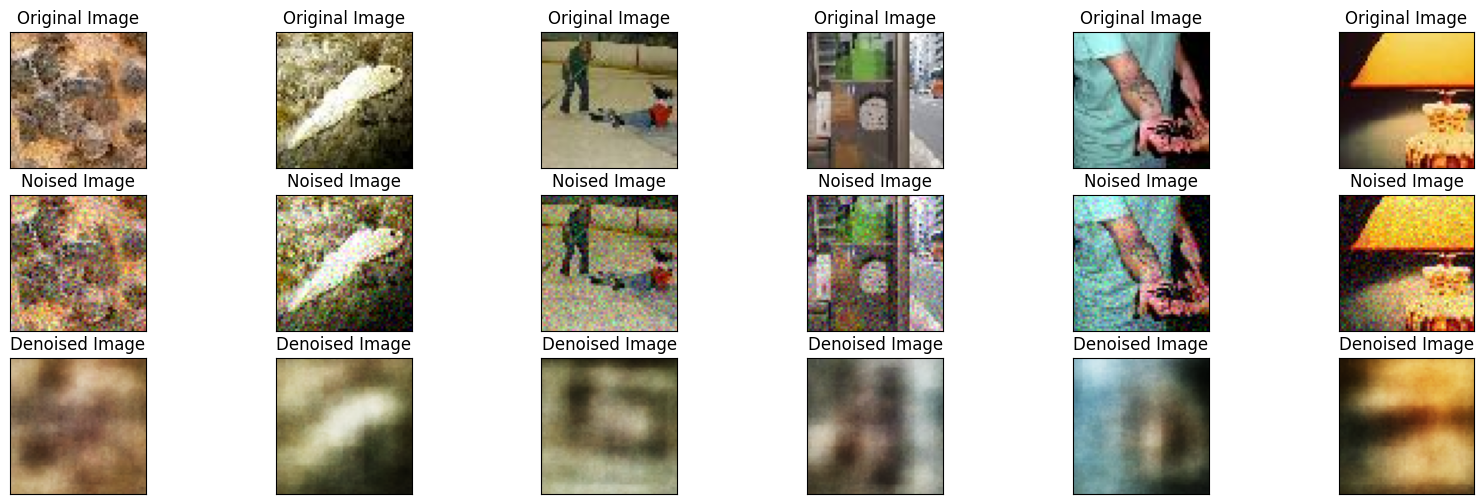

In [11]:
train_target_width = 57
train_target_height = 57

original_shape = (train_target_height, train_target_width, 3)

plt.figure(figsize=(20, 6))
n = 6

for i in range(n):
    # Visualize the original images
    ax = plt.subplot(3, n, i + 1)
    plt.title("Original Image")
    plt.imshow(x_test[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Visualize the noised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.title("Noised Image")
    plt.imshow(Noised_x_test[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Visulaize the denoised images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.title("Denoised Image")
    plt.imshow(Denoised_x_test[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Fitting the Autoencoder on the Original Training Data

In [12]:
autoencoder.fit(x_train, x_train, epochs=7, validation_data=(x_val, x_val))

Epoch 1/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.0225 - val_loss: 0.0245
Epoch 2/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0225 - val_loss: 0.0233
Epoch 3/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0224 - val_loss: 0.0232
Epoch 4/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0224 - val_loss: 0.0236
Epoch 5/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0225 - val_loss: 0.0233
Epoch 6/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0224 - val_loss: 0.0234
Epoch 7/7
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0224 - val_loss: 0.0236


## Using the Auto Encoder in a Split Format as an Image Denoiser

In [13]:
# Encode the test images
Encoded_images = encoder.predict(x_test)

# Add Gaussian noise to the encoded images
Noised_encoded_images = Gaussian_Noise(Encoded_images, mu, sigma)

# Decode the noised encoded images
Decoded_noised_images = decoder.predict(Noised_encoded_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


## Plotting Results

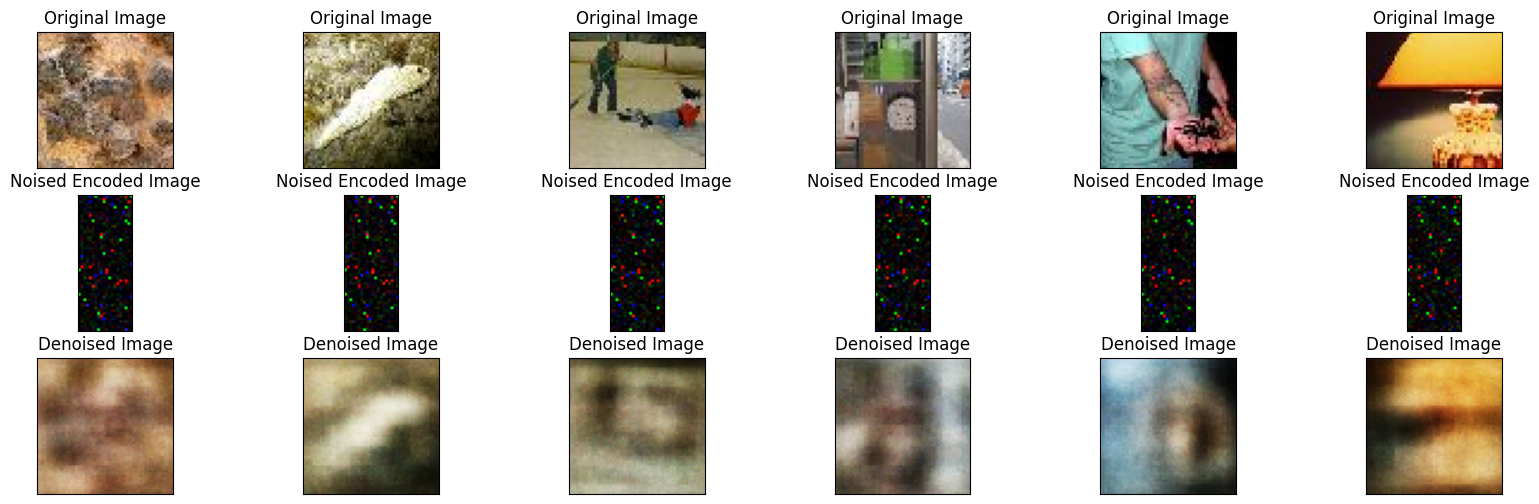

In [19]:
original_shape = (train_target_height, train_target_width, 3)

n = 6
plt.figure(figsize=(20, 6))
for i in range(n):
    # Visualize the original images
    ax = plt.subplot(3, n, i + 1)
    plt.title("Original Image")
    plt.imshow(x_test[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Visulaize the noised encoded images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.title("Noised Encoded Image")
    plt.imshow(Noised_encoded_images[i].reshape(50,20,3))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Visulaize the denoised images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.title("Denoised Image")
    plt.imshow(Decoded_noised_images[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Visual Comparison of Denoising Results

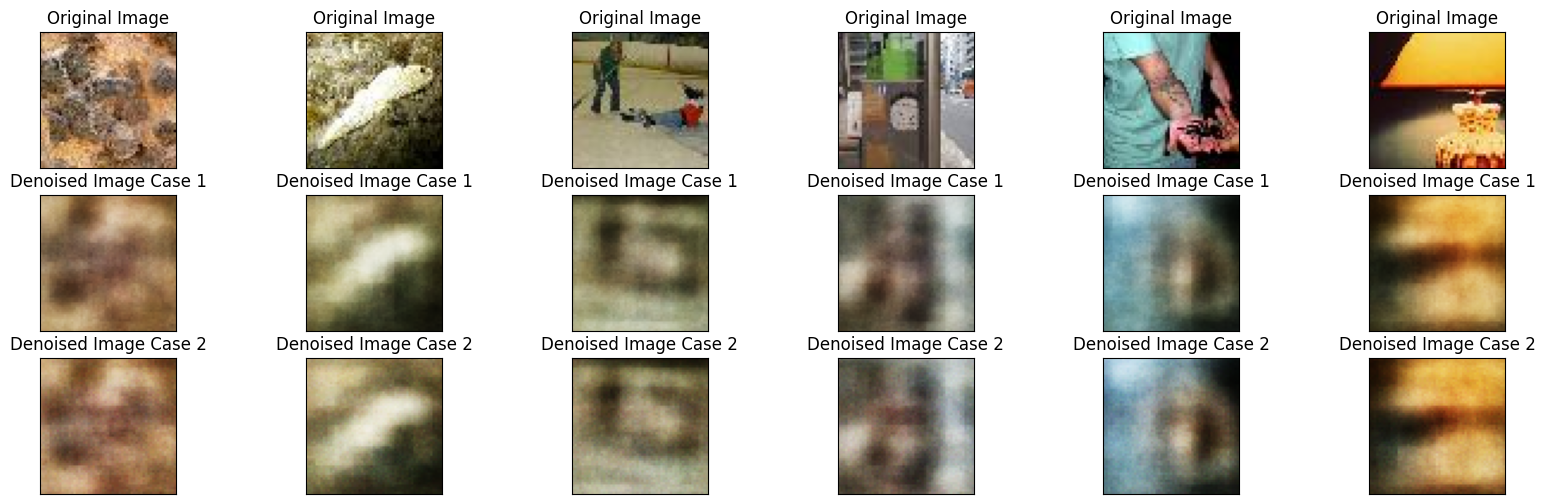

In [20]:
original_shape = (train_target_height, train_target_width, 3)

n = 6
plt.figure(figsize=(20, 6))
for i in range(n):
    # Visualize the original images
    ax = plt.subplot(3, n, i + 1)
    plt.title("Original Image")
    plt.imshow(x_test[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Visulaize the denoised images in case of noising the original images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.title("Denoised Image Case 1")
    plt.imshow(Denoised_x_test[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Visulaize the denoised images in case of noising the encoded images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.title("Denoised Image Case 2")
    plt.imshow(Decoded_noised_images[i].reshape(original_shape))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
plt.show()